# 6.1 – Benchmark Analysis

Loads the Parquet file produced by `scripts/benchmark.py` and computes a full comparative analysis of all counterfactual methods.

**Sections**
1. Load & overview
2. Validity (success rate)
3. Proximity — L2 and L1 distance
4. Sparsity — fraction of changed features
5. Runtime
6. Failure analysis
7. Feature-level change analysis
8. Summary radar chart
9. On-manifoldness

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 4)})

PARQUET_PATH = Path('../results/benchmark_adult.parquet')

## 1. Load & Overview

In [2]:
df = pd.read_parquet(PARQUET_PATH)
print(f'Shape: {df.shape}')
print(f'Methods: {sorted(df["method"].unique())}')
print(f'Spaces:  {sorted(df["space"].unique())}')
df.head(3)

Shape: (500, 39)
Methods: ['dice', 'face', 'growing_spheres', 'my_method', 'nearest_neighbor']
Spaces:  ['raw']


,method,query_idx,space,y_orig,y_cf,success,runtime_s,error,l2_distance,l1_distance,...,x_orig_9,x_cf_9,x_orig_10,x_cf_10,x_orig_11,x_cf_11,x_orig_12,x_cf_12,x_orig_13,x_cf_13
0,dice,211,raw,0,1,True,0.433611,None,1.444508,3.658721,...,0.0,0.522752,-0.144061,0.364337,-0.217141,0.147187,1.579747,1.680508,38.0,37.997696
1,dice,307,raw,1,1,True,0.278094,None,0.665648,1.819155,...,0.0,0.140569,1.248730,1.608618,-0.217141,0.076050,-0.036762,-0.068801,38.0,37.821400
2,dice,327,raw,1,1,True,0.862299,None,0.035580,0.069664,...,0.0,0.000000,0.578152,0.545935,-0.217141,-0.217141,1.579747,1.572825,38.0,37.996674


In [3]:
# Identify feature columns
x_orig_cols = sorted([c for c in df.columns if c.startswith('x_orig_')], key=lambda c: int(c.split('_')[-1]))
x_cf_cols   = sorted([c for c in df.columns if c.startswith('x_cf_')],   key=lambda c: int(c.split('_')[-1]))
n_features = len(x_orig_cols)
print(f'Feature dimension: {n_features}')

# Separate successful rows
df_ok = df[df['success']].copy()

# Methods ordered by validity (descending) for consistent plot ordering
validity_order = (
    df.groupby('method')['success'].mean()
    .sort_values(ascending=False)
    .index.tolist()
)
print(f'Method order (by validity): {validity_order}')

Feature dimension: 14
Method order (by validity): ['face', 'nearest_neighbor', 'my_method', 'dice', 'growing_spheres']


In [4]:
# Per-method counts
summary = (
    df.groupby('method')
    .agg(
        n_total=('success', 'count'),
        n_valid=('success', 'sum'),
        validity_pct=('success', lambda x: 100 * x.mean()),
        l2_mean=('l2_distance', 'mean'),
        l1_mean=('l1_distance', 'mean'),
        sparsity_mean=('l0_sparsity', 'mean'),
        runtime_mean=('runtime_s', 'mean'),
        n_failed=('success', lambda x: (~x).sum()),
    )
    .loc[validity_order]
)
summary.style.format({
    'validity_pct': '{:.1f}%',
    'l2_mean': '{:.3f}',
    'l1_mean': '{:.3f}',
    'sparsity_mean': '{:.3f}',
    'runtime_mean': '{:.3f}s',
})

,n_total,n_valid,validity_pct,l2_mean,l1_mean,sparsity_mean,runtime_mean,n_failed
method,,,,,,,,
face,100,100,100.0%,6.044,11.821,0.455,0.003s,0
nearest_neighbor,100,100,100.0%,5.908,11.060,0.434,0.000s,0
my_method,100,100,100.0%,8.873,15.787,0.494,0.062s,0
dice,100,95,95.0%,1.694,4.338,0.937,0.737s,5
growing_spheres,100,72,72.0%,0.779,2.061,0.720,0.002s,28


## 2. Validity (Success Rate)

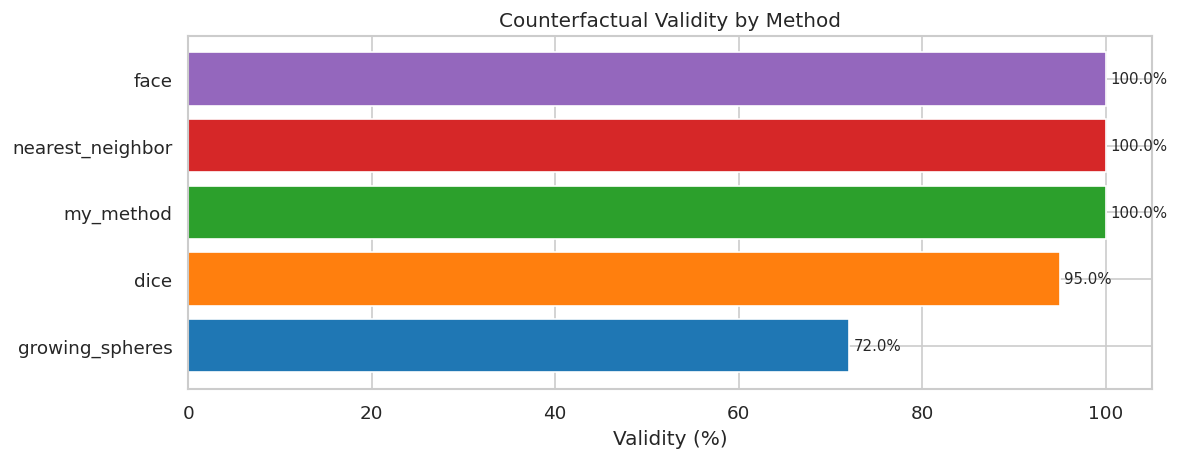

In [5]:
validity = df.groupby('method')['success'].mean().loc[validity_order] * 100

fig, ax = plt.subplots()
bars = ax.barh(validity.index[::-1], validity.values[::-1], color=sns.color_palette('tab10', len(validity)))
ax.set_xlabel('Validity (%)')
ax.set_title('Counterfactual Validity by Method')
ax.set_xlim(0, 105)
for bar, val in zip(bars, validity.values[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Proximity — L2 and L1 Distance

> Only computed over the **shared success set**: queries where **every** method
> found a valid counterfactual.  This removes the selection bias that would
> otherwise make low-validity methods look artificially close (they only
> succeed on easy, near-boundary queries).
>
> `my_method` CFs are now decoded back to raw feature space before storage,
> so distances are directly comparable across all methods.

In [6]:
# Shared success set: query indices where ALL methods returned a valid CF
success_pivot = (
    df.groupby(['method', 'query_idx'])['success']
    .any()
    .unstack('method')
    .fillna(False)
)
shared_idx = success_pivot[success_pivot.all(axis=1)].index.tolist()
df_shared = df_ok[df_ok['query_idx'].isin(shared_idx)].copy()

print(f'Queries with universal success: {len(shared_idx)} / {df["query_idx"].nunique()}')
print('Per-method count in shared set:')
print(df_shared.groupby('method').size().loc[validity_order])

Queries with universal success: 72 / 100
Per-method count in shared set:
method
face                72
nearest_neighbor    72
my_method           72
dice                72
growing_spheres     72
dtype: int64


/tmp/ipykernel_228954/3208043677.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_method, vert=True, patch_artist=True, labels=validity_order)
/tmp/ipykernel_228954/3208043677.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_method, vert=True, patch_artist=True, labels=validity_order)


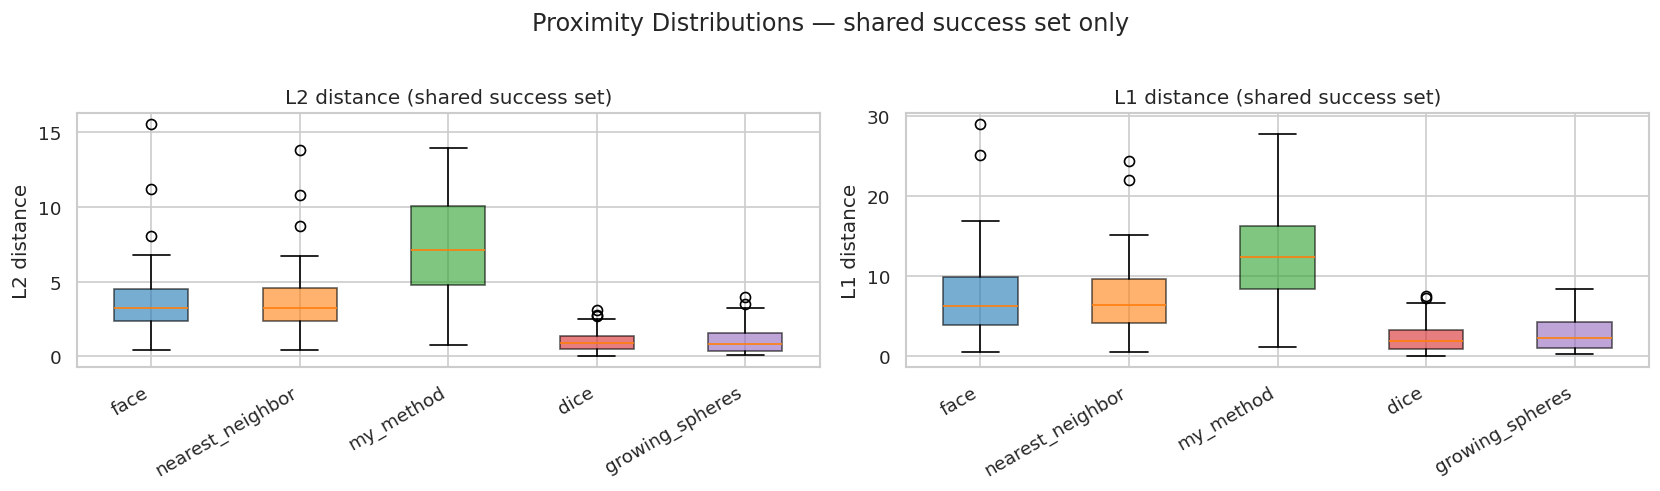

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric, label in zip(axes, ['l2_distance', 'l1_distance'], ['L2 distance', 'L1 distance']):
    data_by_method = [df_shared[df_shared['method'] == m][metric].dropna().values for m in validity_order]
    bp = ax.boxplot(data_by_method, vert=True, patch_artist=True, labels=validity_order)
    palette = sns.color_palette('tab10', len(validity_order))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(f'{label} (shared success set)')
    ax.set_ylabel(label)
    ax.set_xticklabels(validity_order, rotation=30, ha='right')

plt.suptitle('Proximity Distributions — shared success set only', y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Proximity summary statistics (shared success set)
prox_stats = (
    df_shared.groupby('method')[['l2_distance', 'l1_distance']]
    .agg(['mean', 'median', 'std'])
    .loc[validity_order]
)
prox_stats.style.format('{:.3f}')

## 4. Sparsity — Fraction of Changed Features

> Computed on the **shared success set** for the same reason as proximity.

/tmp/ipykernel_228954/3009726245.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_sparsity, vert=True, patch_artist=True, labels=validity_order)


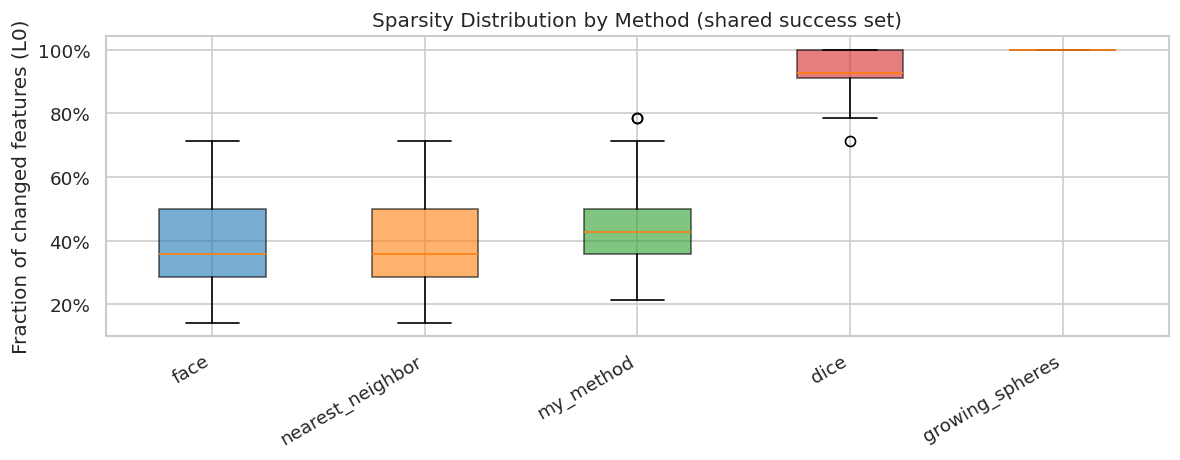

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
data_sparsity = [df_shared[df_shared['method'] == m]['l0_sparsity'].dropna().values for m in validity_order]
bp = ax.boxplot(data_sparsity, vert=True, patch_artist=True, labels=validity_order)
palette = sns.color_palette('tab10', len(validity_order))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Fraction of changed features (L0)')
ax.set_title('Sparsity Distribution by Method (shared success set)')
ax.set_xticklabels(validity_order, rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

## 5. Runtime

/tmp/ipykernel_228954/753072467.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(rt_mean.index, rotation=30, ha='right')
/tmp/ipykernel_228954/753072467.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(rt_mean.index, rotation=30, ha='right')


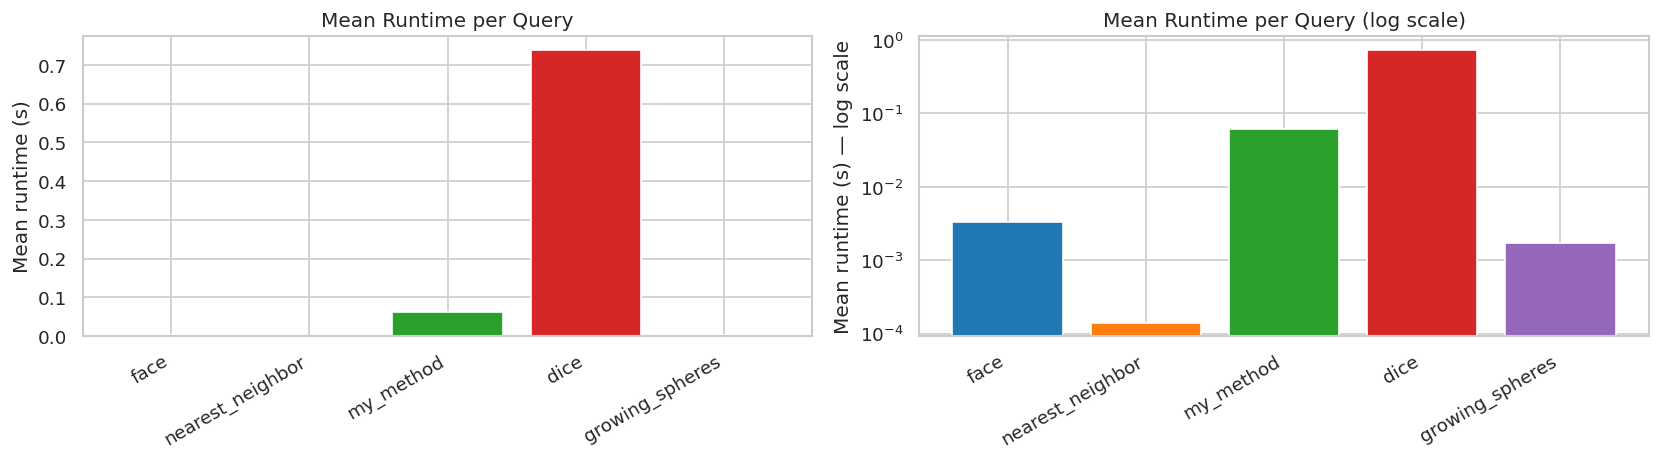

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mean runtime bar chart
rt_mean = df.groupby('method')['runtime_s'].mean().loc[validity_order]
axes[0].bar(rt_mean.index, rt_mean.values, color=sns.color_palette('tab10', len(rt_mean)))
axes[0].set_ylabel('Mean runtime (s)')
axes[0].set_title('Mean Runtime per Query')
axes[0].set_xticklabels(rt_mean.index, rotation=30, ha='right')

# Log-scale version for readability when runtimes differ by orders of magnitude
axes[1].bar(rt_mean.index, rt_mean.values, color=sns.color_palette('tab10', len(rt_mean)))
axes[1].set_yscale('log')
axes[1].set_ylabel('Mean runtime (s) — log scale')
axes[1].set_title('Mean Runtime per Query (log scale)')
axes[1].set_xticklabels(rt_mean.index, rotation=30, ha='right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_228954/1894074972.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(rt_data, vert=True, patch_artist=True, labels=validity_order)


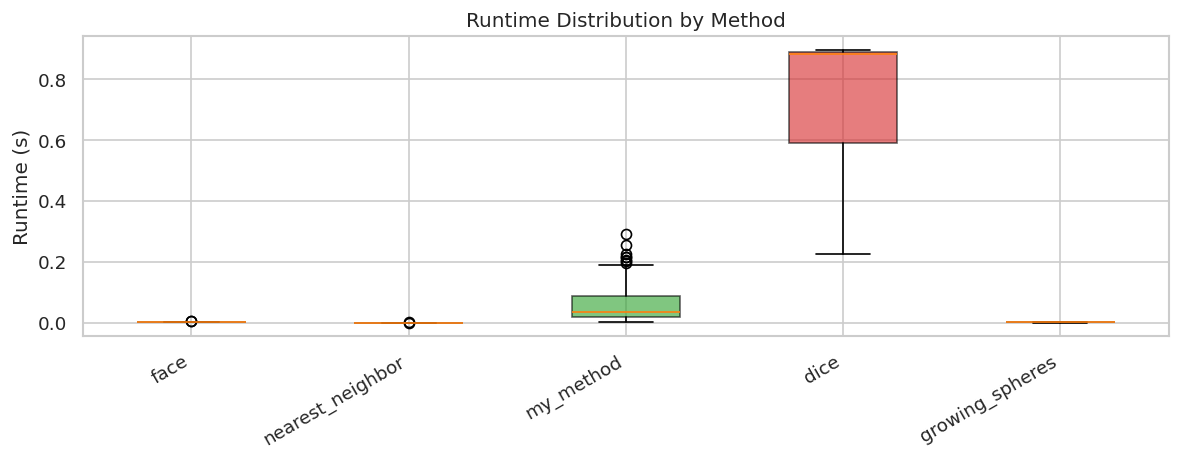

In [11]:
# Full runtime distribution (box plot)
fig, ax = plt.subplots(figsize=(10, 4))
rt_data = [df[df['method'] == m]['runtime_s'].dropna().values for m in validity_order]
bp = ax.boxplot(rt_data, vert=True, patch_artist=True, labels=validity_order)
for patch, color in zip(bp['boxes'], sns.color_palette('tab10', len(validity_order))):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Runtime (s)')
ax.set_title('Runtime Distribution by Method')
ax.set_xticklabels(validity_order, rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 6. Failure Analysis

In [12]:
df_fail = df[~df['success']].copy()
print(f'Total failures: {len(df_fail)} / {len(df)}')

fail_counts = df_fail.groupby('method')['error'].count().loc[
    [m for m in validity_order if m in df_fail['method'].unique()]
]
print('\nFailures per method:')
print(fail_counts.to_string())

Total failures: 33 / 500

Failures per method:
method
dice               0
growing_spheres    0


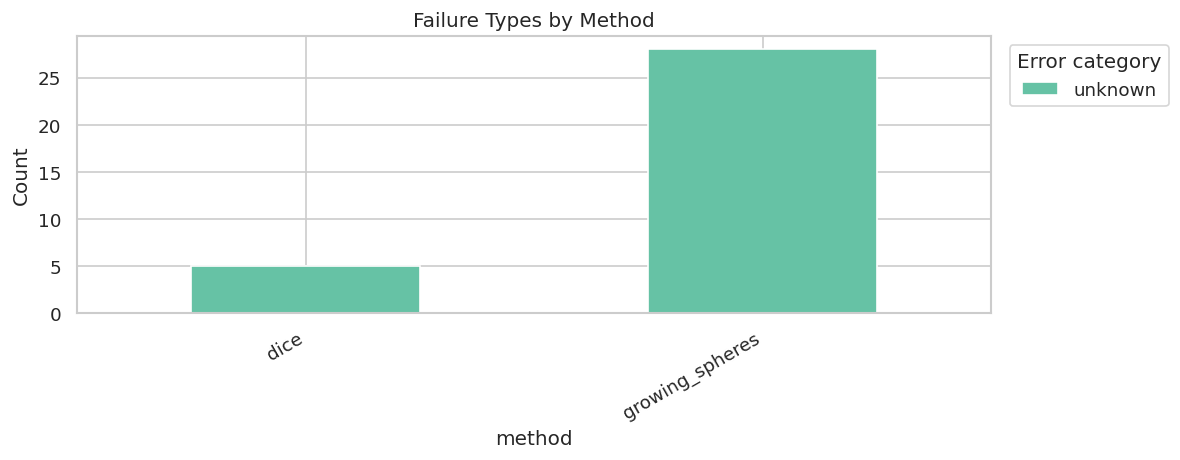

In [13]:
# Error type breakdown per method
if len(df_fail) > 0:
    # Normalize error messages to coarse categories
    def _error_category(msg):
        if pd.isna(msg):
            return 'unknown'
        msg = str(msg)
        if 'timeout' in msg:
            return 'timeout'
        if 'fit_error' in msg or 'build_error' in msg:
            return 'fit/build error'
        if 'no_valid' in msg:
            return 'no valid CF found'
        return 'other'

    df_fail['error_cat'] = df_fail['error'].apply(_error_category)
    pivot = df_fail.pivot_table(index='method', columns='error_cat', aggfunc='size', fill_value=0)
    pivot.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='Set2')
    plt.title('Failure Types by Method')
    plt.ylabel('Count')
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Error category', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print('No failures — all methods succeeded on all queries.')

## 7. Feature-Level Change Analysis

For each method, compute the mean absolute change per feature across all successful counterfactuals.
This shows which features each method tends to modify.
All methods now store CFs in raw feature space.

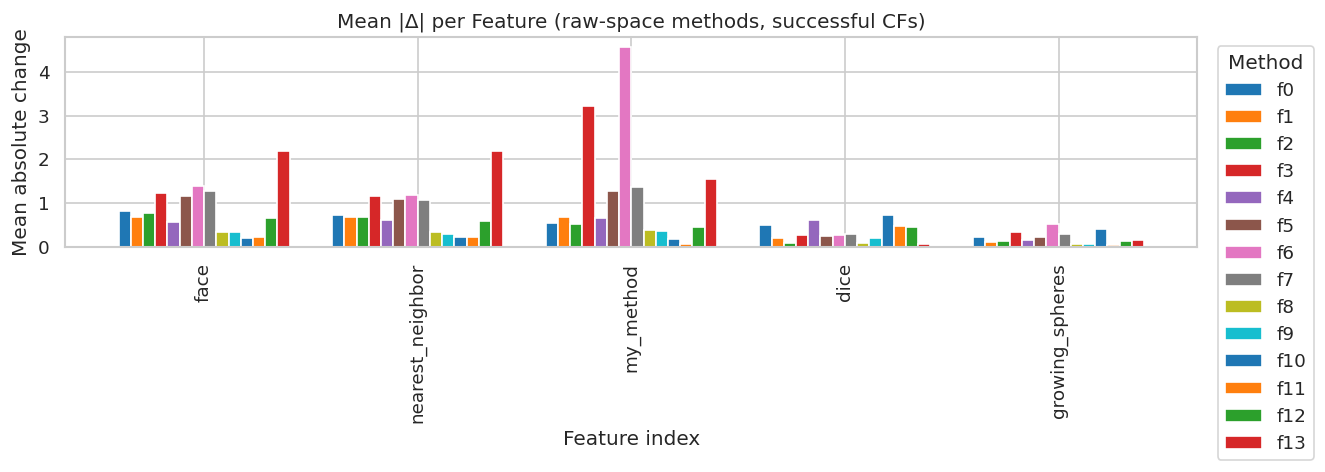

In [14]:
# Only raw-space methods for interpretable feature comparison
raw_methods = [m for m in validity_order if df_ok[df_ok['method'] == m]['space'].eq('raw').any()]

if raw_methods and x_orig_cols:
    feature_changes = {}
    for method in raw_methods:
        sub = df_ok[df_ok['method'] == method]
        if len(sub) == 0:
            continue
        orig = sub[x_orig_cols].values
        cf   = sub[x_cf_cols].values
        feature_changes[method] = np.nanmean(np.abs(cf - orig), axis=0)

    if feature_changes:
        fc_df = pd.DataFrame(feature_changes, index=[f'f{i}' for i in range(n_features)])
        fig, ax = plt.subplots(figsize=(max(10, n_features * 0.8), 4))
        fc_df.T.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title('Mean |Δ| per Feature (raw-space methods, successful CFs)')
        ax.set_xlabel('Feature index')
        ax.set_ylabel('Mean absolute change')
        ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
else:
    print('No raw-space successful CFs available for feature analysis.')

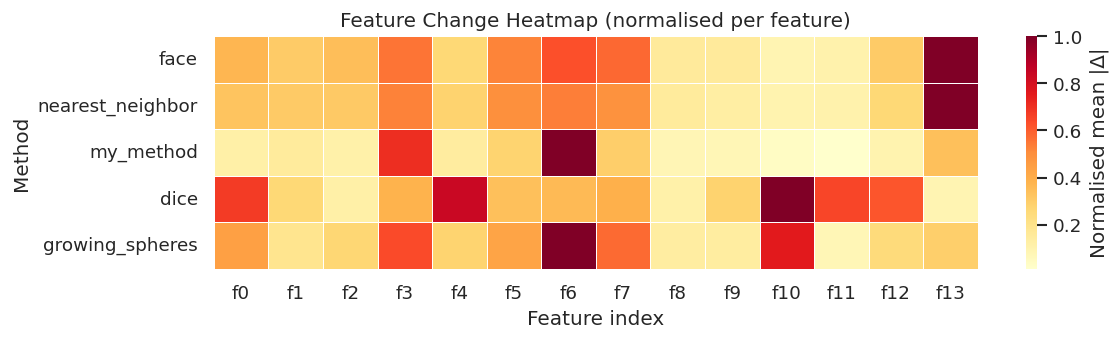

In [15]:
# Heatmap: normalised mean |Δ| per feature per method
if feature_changes:
    fc_norm = fc_df.div(fc_df.max(axis=0).replace(0, 1), axis=1)  # normalise each feature to [0,1]
    fig, ax = plt.subplots(figsize=(max(10, n_features * 0.7), max(3, len(feature_changes) * 0.6)))
    sns.heatmap(
        fc_norm.T,
        ax=ax,
        cmap='YlOrRd',
        linewidths=0.3,
        annot=False,
        cbar_kws={'label': 'Normalised mean |Δ|'},
    )
    ax.set_title('Feature Change Heatmap (normalised per feature)')
    ax.set_xlabel('Feature index')
    ax.set_ylabel('Method')
    plt.tight_layout()
    plt.show()

## 8. Summary Radar Chart

Combines validity, proximity (inverted), sparsity (inverted), and runtime (inverted) into a single radar plot.  
All axes are normalised to [0, 1] with **higher = better** on every axis.
Proximity and sparsity use the **shared success set** for a fair comparison.

                  validity  1-L2_norm  1-L1_norm  1-sparsity  1-rt_norm
method                                                                 
face                  1.00      0.503      0.394       0.604      0.996
nearest_neighbor      1.00      0.515      0.429       0.616      1.000
my_method             1.00      0.000      0.000       0.556      0.916
dice                  0.95      0.867      0.813       0.067      0.000
growing_spheres       0.72      0.853      0.769       0.000      0.998


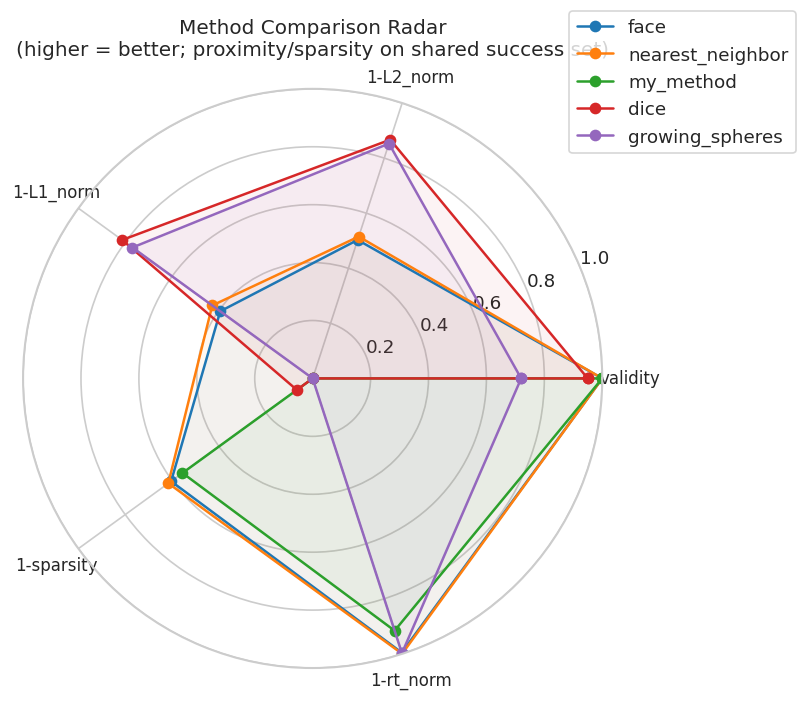

In [16]:
radar_metrics = {
    'validity':   df.groupby('method')['success'].mean(),
    '1-L2_norm':  1 - df_shared.groupby('method')['l2_distance'].mean().pipe(lambda s: s / s.max().clip(1e-9)),
    '1-L1_norm':  1 - df_shared.groupby('method')['l1_distance'].mean().pipe(lambda s: s / s.max().clip(1e-9)),
    '1-sparsity': 1 - df_shared.groupby('method')['l0_sparsity'].mean(),
    '1-rt_norm':  1 - df.groupby('method')['runtime_s'].mean().pipe(lambda s: s / s.max().clip(1e-9)),
}

radar_df = pd.DataFrame(radar_metrics).loc[validity_order].fillna(0).clip(0, 1)
print(radar_df.round(3))

categories = list(radar_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
palette = sns.color_palette('tab10', len(validity_order))

for i, method in enumerate(validity_order):
    values = radar_df.loc[method].tolist() + [radar_df.loc[method].tolist()[0]]
    ax.plot(angles, values, 'o-', linewidth=1.5, label=method, color=palette[i])
    ax.fill(angles, values, alpha=0.05, color=palette[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 1)
ax.set_title('Method Comparison Radar\n(higher = better; proximity/sparsity on shared success set)', size=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

## 9. On-Manifoldness

Measures whether generated counterfactuals lie on the data manifold.
Four complementary metrics are fitted on the **training set** and evaluated on all successful CFs.
All methods (including `my_method`, whose CFs are now decoded to raw feature space) use the same raw-space estimators.

| Metric | Interpretation |
|--------|----------------|
| **LOF score** | Local Outlier Factor — score ≈ −1 = in-distribution, score << −1 = outlier (sklearn returns negative LOF) |
| **Isolation Forest score** | Anomaly score; higher (→ 0) = more normal, lower (→ −0.5) = more anomalous |
| **KDE log-density** | Log p̂(x); higher = more likely under the training distribution |
| **NN distance** | L2 distance to nearest training neighbour; lower = closer to a real training point |

In [17]:
import sys
sys.path.insert(0, str(Path('../src')))

import yaml

from counterfactuals.experiments.runner import create_default_registries

CONFIG_PATH = Path('../configs/benchmark_adult.yaml')
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

registries = create_default_registries()
dataset = registries["dataset"].create(cfg["dataset"]["name"], **cfg["dataset"]["params"])
dataset.load()
x_train_full, y_train_full = dataset.get_train()
print(f'Training set shape: {x_train_full.shape}')

Training set shape: (39074, 14)


In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import KernelDensity, LocalOutlierFactor, NearestNeighbors

# Scott's bandwidth rule for KDE
bw = x_train_full.shape[0] ** (-1.0 / (x_train_full.shape[1] + 4))

print(f"Fitting LOF       (n_neighbors=20) ...")
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof.fit(x_train_full)

print(f"Fitting Isolation Forest ...")
iso = IsolationForest(n_estimators=200, random_state=42)
iso.fit(x_train_full)

print(f"Fitting KDE       (bandwidth={bw:.4f}, Scott's rule) ...")
kde = KernelDensity(kernel='gaussian', bandwidth=bw)
kde.fit(x_train_full)

print(f"Building NN index ...")
nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(x_train_full)

print("Done — all manifold estimators fitted.")

Fitting LOF       (n_neighbors=20) ...
Fitting Isolation Forest ...
Fitting KDE       (bandwidth=0.5558, Scott's rule) ...
Building NN index ...
Done — all manifold estimators fitted.


In [19]:
# Score all successful CFs — all methods are now in raw feature space
df_manifold = df_ok.copy()

X_cf_all = df_manifold[x_cf_cols].values.astype(float)
df_manifold['lof_score']       = lof.score_samples(X_cf_all)
df_manifold['iso_score']       = iso.score_samples(X_cf_all)
df_manifold['kde_log_density'] = kde.score_samples(X_cf_all)
df_manifold['nn_distance']     = nn.kneighbors(X_cf_all)[0].ravel()

all_manifold_methods = [m for m in validity_order if m in df_manifold['method'].unique()]

print(f"Scored {len(df_manifold)} CFs across methods: {all_manifold_methods}")
display(
    df_manifold.groupby('method')[['lof_score', 'iso_score', 'kde_log_density', 'nn_distance']]
    .agg(['mean', 'median'])
    .loc[all_manifold_methods]
    .style.format('{:.3f}')
)

Scored 467 CFs across methods: ['face', 'nearest_neighbor', 'my_method', 'dice', 'growing_spheres']


/tmp/ipykernel_228954/1678366550.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_method, vert=True, patch_artist=True, labels=all_manifold_methods)
/tmp/ipykernel_228954/1678366550.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_method, vert=True, patch_artist=True, labels=all_manifold_methods)
/tmp/ipykernel_228954/1678366550.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_method, vert=True, patch_artist=True, labels=all_manifold_methods)
/tmp/ipykernel_228954/1678366550.py:16: MatplotlibDeprecationWarning: The 'labels' parameter o

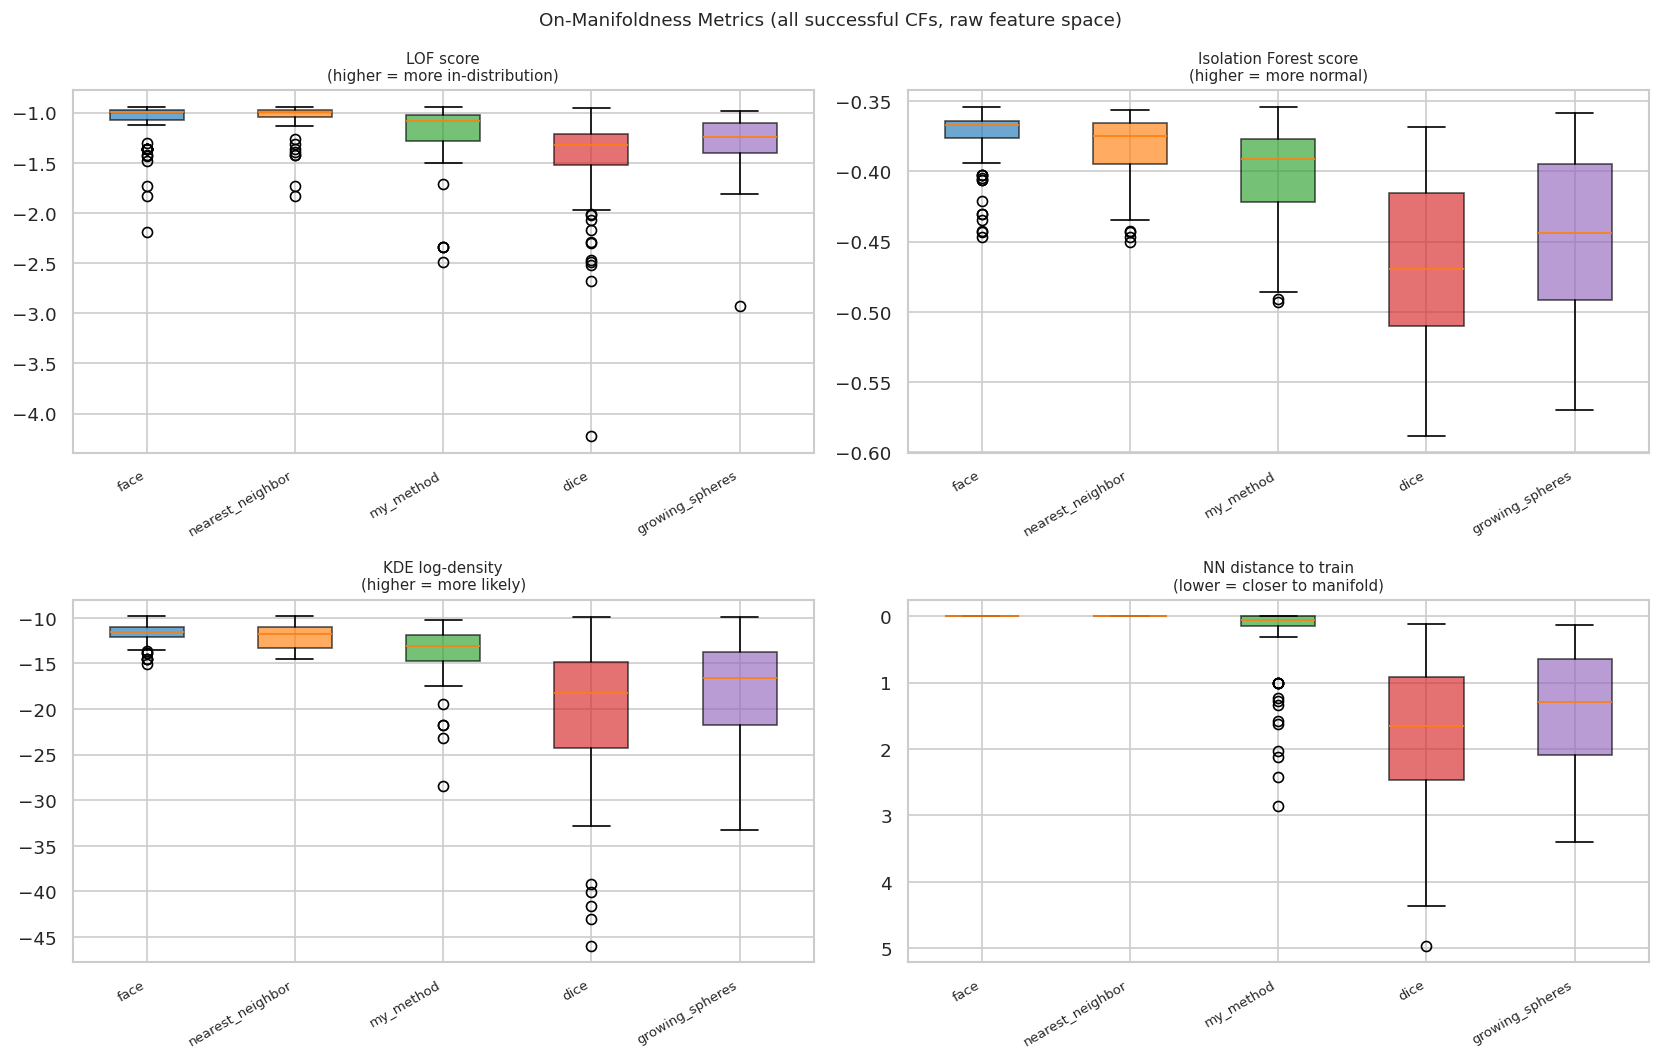

In [20]:
manifold_axes = [
    ('lof_score',       'LOF score\n(higher = more in-distribution)',         False),
    ('iso_score',       'Isolation Forest score\n(higher = more normal)',     False),
    ('kde_log_density', 'KDE log-density\n(higher = more likely)',            False),
    ('nn_distance',     'NN distance to train\n(lower = closer to manifold)', True),
]

pal = sns.color_palette('tab10', len(all_manifold_methods))
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (metric, label, invert) in zip(axes.ravel(), manifold_axes):
    data_by_method = [
        df_manifold[df_manifold['method'] == m][metric].dropna().values
        for m in all_manifold_methods
    ]
    bp = ax.boxplot(data_by_method, vert=True, patch_artist=True, labels=all_manifold_methods)
    for patch, color in zip(bp['boxes'], pal):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax.set_title(label, fontsize=9)
    ax.set_xticklabels(all_manifold_methods, rotation=30, ha='right', fontsize=8)
    if invert:
        ax.invert_yaxis()

plt.suptitle('On-Manifoldness Metrics (all successful CFs, raw feature space)', fontsize=11)
plt.tight_layout()
plt.show()

/tmp/ipykernel_228954/1038558088.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(all_data, vert=True, patch_artist=True, labels=all_labels)
/tmp/ipykernel_228954/1038558088.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(all_data, vert=True, patch_artist=True, labels=all_labels)
/tmp/ipykernel_228954/1038558088.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(all_data, vert=True, patch_artist=True, labels=all_labels)
/tmp/ipykernel_228954/1038558088.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since

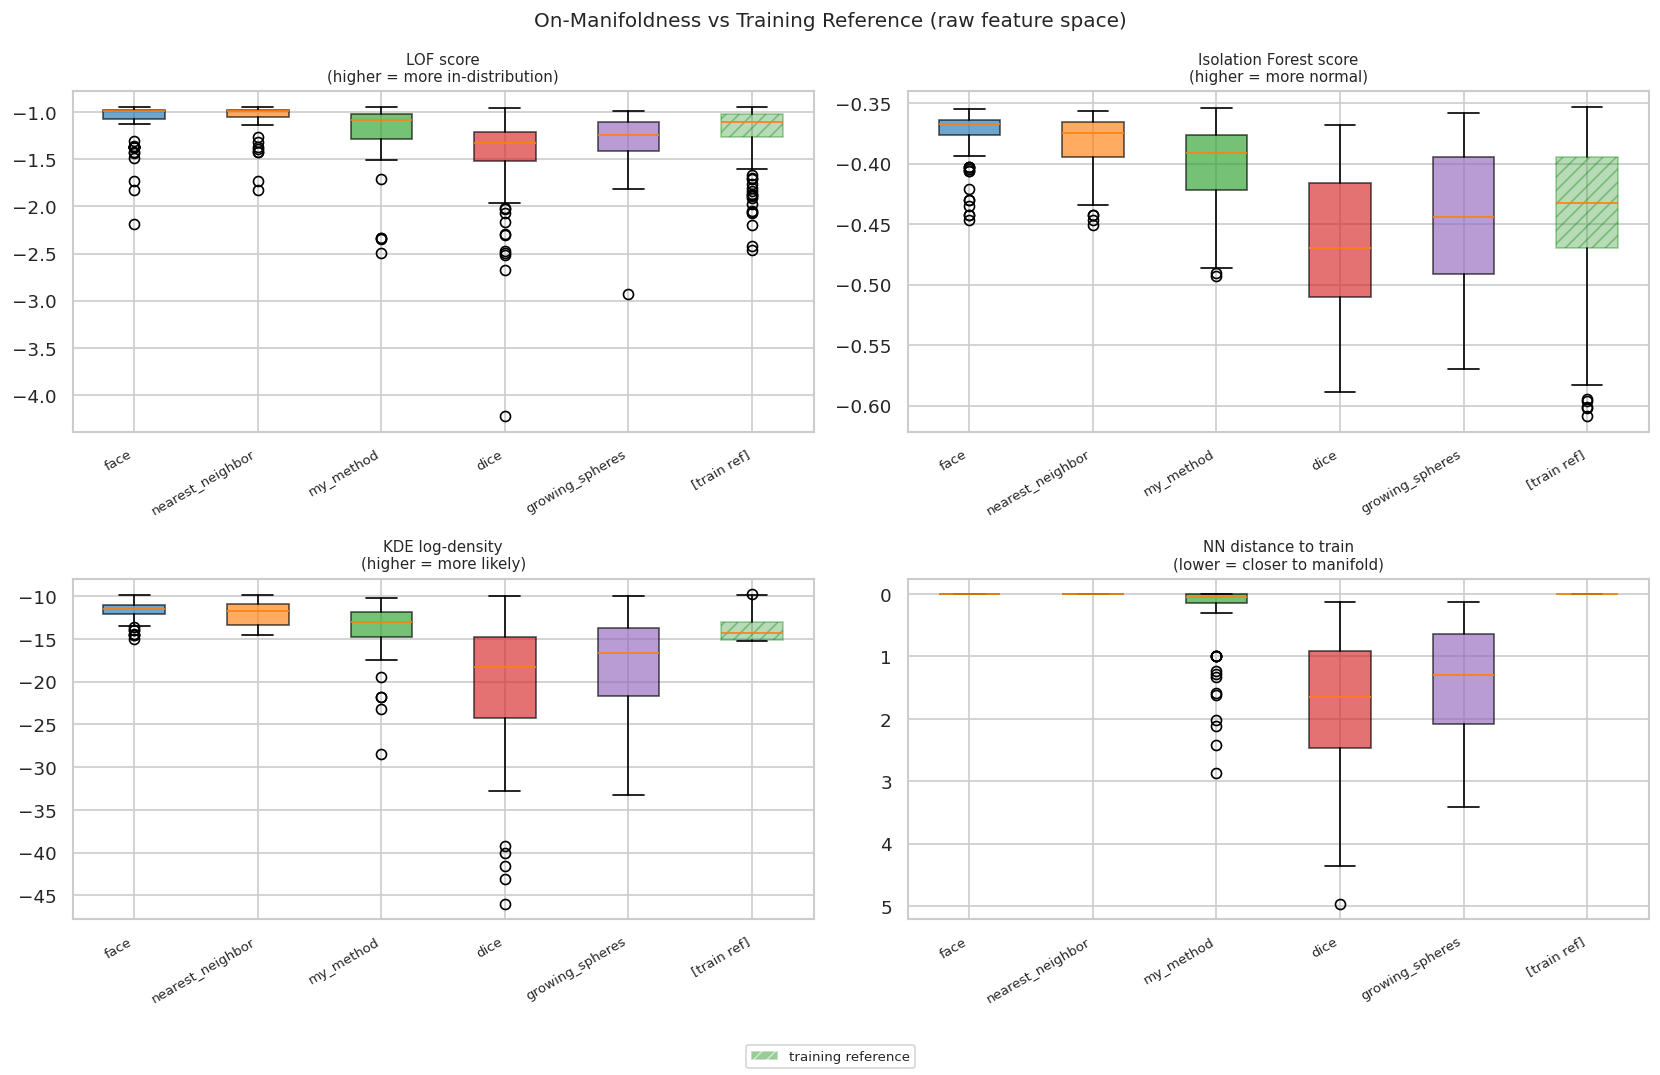

In [21]:
# Training-set reference baseline for on-manifoldness
rng_ref = np.random.default_rng(42)
ref_idx = rng_ref.choice(len(x_train_full), size=min(500, len(x_train_full)), replace=False)
X_ref = x_train_full[ref_idx]

ref_scores = {
    'lof_score':       lof.score_samples(X_ref),
    'iso_score':       iso.score_samples(X_ref),
    'kde_log_density': kde.score_samples(X_ref),
    'nn_distance':     nn.kneighbors(X_ref)[0].ravel(),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (metric, label, invert) in zip(axes.ravel(), manifold_axes):
    data_by_method = [
        df_manifold[df_manifold['method'] == m][metric].dropna().values
        for m in all_manifold_methods
    ]
    all_labels = all_manifold_methods + ['[train ref]']
    all_data   = data_by_method + [ref_scores[metric]]

    bp = ax.boxplot(all_data, vert=True, patch_artist=True, labels=all_labels)
    for i, patch in enumerate(bp['boxes']):
        if i < len(all_manifold_methods):
            patch.set_facecolor(pal[i])
            patch.set_alpha(0.65)
        else:
            patch.set_facecolor((0.2, 0.6, 0.2))
            patch.set_alpha(0.35)
            patch.set_hatch('///')
            patch.set_edgecolor('green')
    ax.set_title(label, fontsize=9)
    ax.set_xticklabels(all_labels, rotation=30, ha='right', fontsize=8)
    if invert:
        ax.invert_yaxis()

from matplotlib.patches import Patch
handles = [Patch(facecolor=(0.2, 0.6, 0.2), hatch='///', alpha=0.5, label='training reference')]
fig.legend(handles=handles, loc='lower center', ncol=1, fontsize=8, frameon=True)
plt.suptitle('On-Manifoldness vs Training Reference (raw feature space)', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 10. CF Robustness

Two complementary analyses measuring how **stable** each method's counterfactuals are to small perturbations.

### 10a — Empirical margin (all methods)

For each successful CF `x_cf`, we add Gaussian noise of increasing L2 magnitude ε
and check whether the perturbed CF is still classified as the target class.
A method whose CFs sit **far from the decision boundary** will maintain high
validity even at large ε.

### 10b — Certified radius (my_method only)

`CertifiedAtlas.find_counterfactual(delta=δ)` erodes each polytope inward by δ,
guaranteeing that **any point within δ of the returned CF** (in the atlas norm)
is classified as the target class.  We sweep δ and record the largest value for
which a valid CF is still found — this is the **certified robustness radius** for
that query.

The gap between 10a (empirical) and 10b (certified) shows how conservative the
LiRPA certificate is relative to the true margin.

/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 158 is empty! self.labels_[self.medoid_indices_[158]] may not be labeled with its corresponding cluster (158).
  warnings.warn(
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 601 is empty! self.labels_[self.medoid_indices_[601]] may not be labeled with its corresponding cluster (601).
  warnings.warn(
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 736 is empty! self.labels_[self.medoid_indices_[736]] may not be labeled with its corresponding cluster (736).
  warnings.warn(


sklearn MLP train acc: 0.832


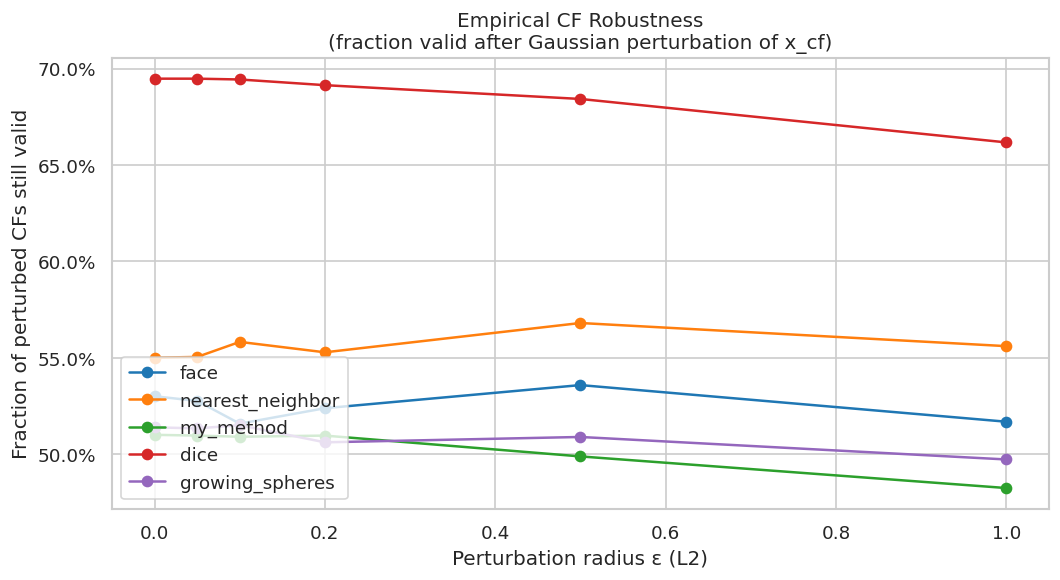

method   face  nearest_neighbor  my_method   dice  growing_spheres
eps                                                               
0.00    0.530             0.550      0.510  0.695            0.514
0.05    0.528             0.550      0.510  0.695            0.513
0.10    0.516             0.558      0.509  0.694            0.515
0.20    0.524             0.553      0.510  0.691            0.506
0.50    0.536             0.568      0.499  0.684            0.509
1.00    0.517             0.556      0.482  0.662            0.497


In [22]:
## 10a — Empirical CF robustness (all methods)
#
# For each successful CF x_cf, we sample K random unit-direction perturbations
# at each ε level and record the fraction that remain in the target class.
# The sklearn MLP (raw-space) is used for all methods; my_method CFs are now
# decoded to raw space so the same model applies.

from sklearn.neural_network import MLPClassifier

# Re-fit the same sklearn MLP used during benchmarking (same seed, same train set).
rng_bench = np.random.default_rng(42)
n_train_cfg = 1000
try:
    from sklearn_extra.cluster import KMedoids
    km = KMedoids(n_clusters=n_train_cfg, random_state=42)
    km.fit(x_train_full)
    x_train_bm = x_train_full[km.medoid_indices_]
    y_train_bm = y_train_full[km.medoid_indices_]
except ImportError:
    idx_bm = rng_bench.choice(len(x_train_full), size=n_train_cfg, replace=False)
    x_train_bm = x_train_full[idx_bm]
    y_train_bm = y_train_full[idx_bm]

clf_raw = MLPClassifier(random_state=42, max_iter=500)
clf_raw.fit(x_train_bm, y_train_bm)
print(f'sklearn MLP train acc: {clf_raw.score(x_train_bm, y_train_bm):.3f}')

# ── Perturbation sweep ────────────────────────────────────────────────────────
EPS_VALUES = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]
N_SAMPLES   = 50      # perturbation draws per CF per ε

rng_rob = np.random.default_rng(0)
results_rob = []  # list of dicts {method, eps, frac_valid}

for method in validity_order:
    sub = df_ok[df_ok['method'] == method]
    if len(sub) == 0:
        continue
    X_cf = sub[x_cf_cols].values.astype(float)
    Y_target = (1 - sub['y_orig'].values).astype(int)   # target class for each CF

    for eps in EPS_VALUES:
        fracs = []
        for x_cf_i, y_t in zip(X_cf, Y_target):
            if eps == 0.0:
                preds = clf_raw.predict(x_cf_i[None, :])
                fracs.append(int(preds[0] == y_t))
            else:
                # K Gaussian perturbations normalised to L2 norm ε
                noise = rng_rob.standard_normal((N_SAMPLES, len(x_cf_i)))
                norms = np.linalg.norm(noise, axis=1, keepdims=True)
                noise = noise / norms * eps
                X_pert = x_cf_i[None, :] + noise
                preds = clf_raw.predict(X_pert)
                fracs.append(np.mean(preds == y_t))
        results_rob.append({'method': method, 'eps': eps, 'frac_valid': np.mean(fracs)})

rob_df = pd.DataFrame(results_rob)

fig, ax = plt.subplots(figsize=(9, 5))
pal = sns.color_palette('tab10', len(validity_order))
for i, method in enumerate(validity_order):
    sub_r = rob_df[rob_df['method'] == method]
    ax.plot(sub_r['eps'], sub_r['frac_valid'], 'o-', label=method, color=pal[i])

ax.set_xlabel('Perturbation radius ε (L2)')
ax.set_ylabel('Fraction of perturbed CFs still valid')
ax.set_title('Empirical CF Robustness\n(fraction valid after Gaussian perturbation of x_cf)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

print(rob_df.pivot(index='eps', columns='method', values='frac_valid')
      .loc[:, validity_order].round(3).to_string())

Building certified atlas (eps in [0.008333, 4.959] (NearestOppositeClassClearanceStrategy), L1 norm)...
  Computing LiRPA bounds...


Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:09<00:00,  4.59s/it]


  Building BVH spatial indices...
    Class 0: 500 polytopes, tree depth 10
    Class 1: 500 polytopes, tree depth 10
Done! Total: 1000 polytopes across 2 classes
CertifiedAtlas Summary
Classes: 2
Perturbation: eps in [0.008333, 4.959] (NearestOppositeClassClearanceStrategy), L1 norm
Device: cpu

  Class 0:  500 polytopes (BVH depth 10)
  Class 1:  500 polytopes (BVH depth 10)

Total polytopes: 1000

Certified radii (n=40 queries):
  mean=1.000  median=1.000  max=1.000


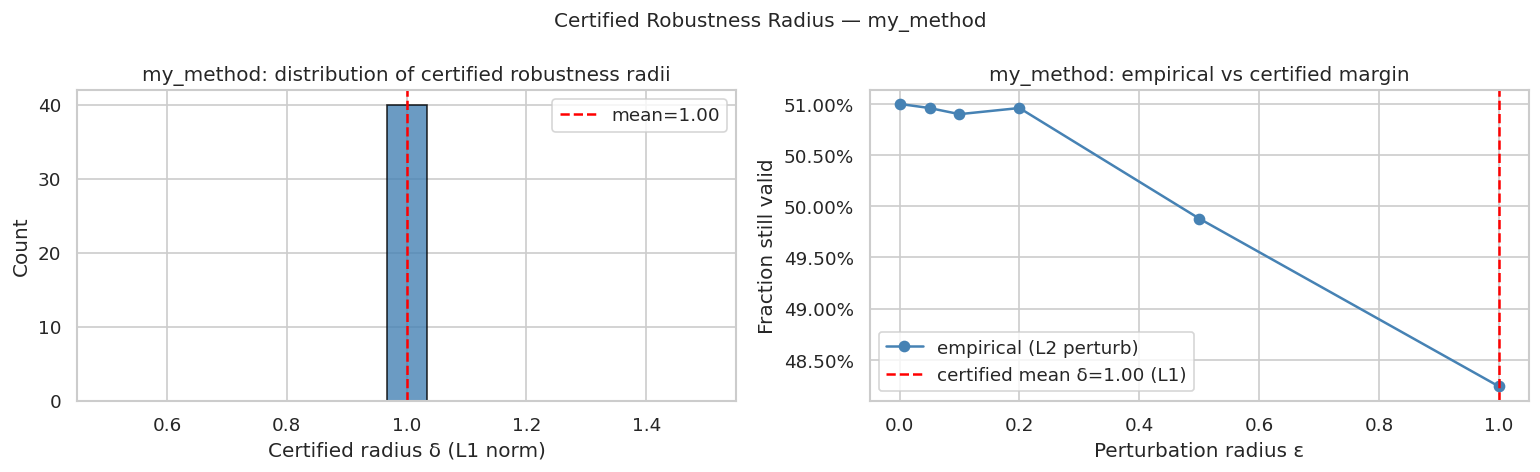

In [23]:
## 10b — Certified robustness radius (my_method only)
#
# Re-build the atlas (same config as benchmark) and sweep the delta parameter.
# delta erodes each polytope inward: any point within delta of the returned CF
# (in the atlas L1 norm) is guaranteed to be classified as the target class.
# The largest delta for which find_counterfactual() still returns success is
# the certified radius for that query.

import torch
from torch.utils.data import TensorDataset

from models.classifiers import TabularClassifier
from preimage_sampling import CertifiedAtlas, NearestOppositeClassClearanceStrategy
from training.datamodules.adult import CARDINALITIES, INPUT_TYPES
from training.lit_classifier import LitClassifier

_my_cfg = next((m for m in cfg.get('methods', []) if m['name'] == 'my_method'), None)
if _my_cfg is None:
    print('my_method not in config — skipping 10b.')
else:
    _ckpt   = Path('..') / _my_cfg['params']['checkpoint']
    _device = _my_cfg['params'].get('device', 'cpu')
    _eps_alpha  = float(_my_cfg['params'].get('eps_alpha', 0.25))
    _k_per_cls  = int(_my_cfg['params'].get('k_per_class', 500))
    _norm       = int(_my_cfg['params'].get('norm', 1))
    _batch_size = int(_my_cfg['params'].get('batch_size', 256))

    # Load model
    backbone = TabularClassifier(
        input_types=INPUT_TYPES, cardinalities=CARDINALITIES,
        embedding_dim=1, hidden_dims=[64, 32], num_classes=2,
    )
    lit = LitClassifier.load_from_checkpoint(str(_ckpt), model=backbone, map_location=_device)
    _model = lit.model.eval().to(_device)

    # Embed training set and build medoid atlas (mirrors benchmark.py)
    with torch.no_grad():
        z_train_10b = _model.embed(torch.from_numpy(x_train_full).to(_device)).cpu().numpy().astype(np.float32)

    try:
        from sklearn_extra.cluster import KMedoids as _KM
        def _med_idx(X, k):
            km = _KM(n_clusters=min(k, len(X)), metric='euclidean', method='alternate', random_state=42)
            km.fit(X); return km.medoid_indices_
    except ImportError:
        from sklearn.cluster import KMeans as _KMeans
        from sklearn.metrics import pairwise_distances as _pw
        def _med_idx(X, k):
            km = _KMeans(n_clusters=min(k, len(X)), random_state=42, n_init='auto')
            km.fit(X)
            return _pw(km.cluster_centers_, X).argmin(axis=1)

    z_parts, y_parts = [], []
    for cls in np.unique(y_train_full):
        cidx = np.where(y_train_full == cls)[0]
        midx = _med_idx(z_train_10b[cidx], _k_per_cls)
        z_parts.append(torch.from_numpy(z_train_10b[cidx[midx]]).float())
        y_parts.append(torch.full((len(midx),), int(cls), dtype=torch.long))
    med_ds = TensorDataset(torch.cat(z_parts), torch.cat(y_parts))

    eps_strat = NearestOppositeClassClearanceStrategy(alpha=_eps_alpha)
    atlas_10b = CertifiedAtlas(_model.net, med_ds, device=_device)
    atlas_10b.build(eps_strategy=eps_strat, norm=_norm, batch_size=_batch_size)
    print(atlas_10b.summary())

    # Queries: embed the test queries used in the benchmark (same seed)
    rng42 = np.random.default_rng(42)
    _, y_test_full = dataset.get_train()   # not used directly
    x_test_full, _ = dataset.get_test() if hasattr(dataset, 'get_test') else (None, None)
    if x_test_full is None:
        print('get_test() not available — skipping.')
    else:
        q_size = min(cfg['sampling']['n_queries'], len(x_test_full))
        q_idx_10b = np.sort(rng42.choice(len(x_test_full), size=q_size, replace=False))
        x_q_raw = x_test_full[q_idx_10b]
        with torch.no_grad():
            z_q_10b = _model.embed(torch.from_numpy(x_q_raw).to(_device)).cpu().numpy().astype(np.float32)

        # For my_method successful queries, sweep delta
        my_ok_idx = set(df_ok[df_ok['method'] == 'my_method']['query_idx'].tolist())
        DELTA_SWEEP = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]

        cert_radii = []
        for qi, (orig_idx, z_q) in enumerate(zip(q_idx_10b, z_q_10b)):
            if orig_idx not in my_ok_idx:
                continue
            target_cls = 1 - int(atlas_10b.model(
                torch.from_numpy(z_q[None, :]).to(_device)
            ).argmax(dim=1).item())
            rad = 0.0
            for d in DELTA_SWEEP:
                res = atlas_10b.find_counterfactual(z_q, target_class=target_cls, delta=d)
                if res.success:
                    rad = d
                else:
                    break
            cert_radii.append(rad)

        cert_radii = np.array(cert_radii)
        print(f'\nCertified radii (n={len(cert_radii)} queries):')
        print(f'  mean={cert_radii.mean():.3f}  median={np.median(cert_radii):.3f}'
              f'  max={cert_radii.max():.3f}')

        # Compare to empirical margin from 10a
        my_emp = rob_df[(rob_df['method'] == 'my_method')].set_index('eps')['frac_valid']

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        axes[0].hist(cert_radii, bins=15, edgecolor='k', color='steelblue', alpha=0.8)
        axes[0].axvline(cert_radii.mean(), color='red', linestyle='--', label=f'mean={cert_radii.mean():.2f}')
        axes[0].set_xlabel('Certified radius δ (L1 norm)')
        axes[0].set_ylabel('Count')
        axes[0].set_title('my_method: distribution of certified robustness radii')
        axes[0].legend()

        axes[1].plot(my_emp.index, my_emp.values, 'o-', color='steelblue', label='empirical (L2 perturb)')
        axes[1].axvline(cert_radii.mean(), color='red', linestyle='--', label=f'certified mean δ={cert_radii.mean():.2f} (L1)')
        axes[1].set_xlabel('Perturbation radius ε')
        axes[1].set_ylabel('Fraction still valid')
        axes[1].set_title('my_method: empirical vs certified margin')
        axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        axes[1].legend()

        plt.suptitle('Certified Robustness Radius — my_method', fontsize=12)
        plt.tight_layout()
        plt.show()

## Appendix: Pairwise Proximity–Validity Trade-off

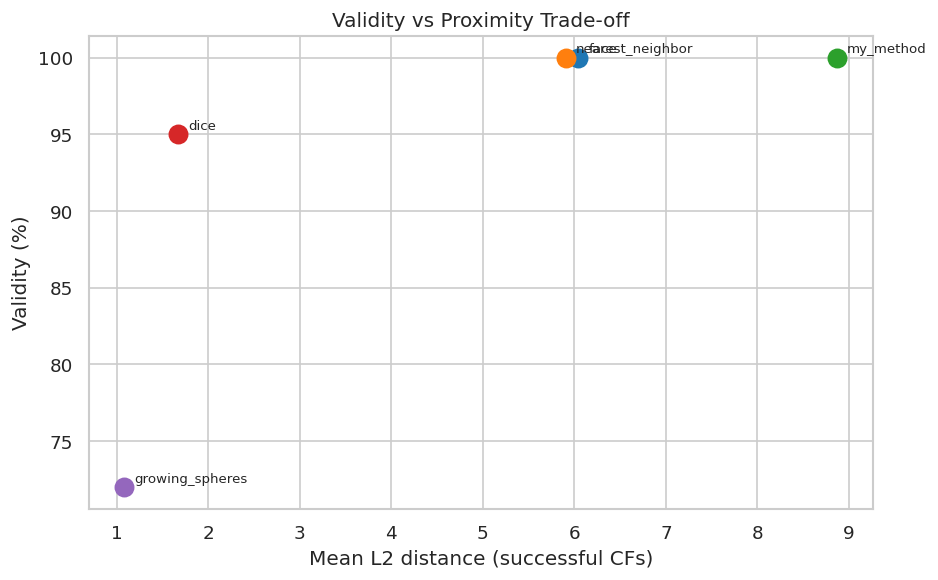

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

for i, method in enumerate(validity_order):
    sub = df[df['method'] == method]
    v = 100 * sub['success'].mean()
    l2 = sub[sub['success']]['l2_distance'].mean()
    ax.scatter(l2, v, s=120, color=palette[i], zorder=3)
    ax.annotate(method, (l2, v), textcoords='offset points', xytext=(6, 3), fontsize=8)

ax.set_xlabel('Mean L2 distance (successful CFs)')
ax.set_ylabel('Validity (%)')
ax.set_title('Validity vs Proximity Trade-off')
plt.tight_layout()
plt.show()